# 🤖 AI Image Detector — v3 (Metadata-Enhanced)
### Detect whether an image is AI-Generated or Real (Human-Created)

**What changed in v3:**
- 🏷️ Added a brand-new **Metadata Forensics** stage. It inspects EXIF, PNG
  text chunks, and XMP-style fields for:
  - **Direct AI-generator signatures** — tool names (Midjourney, DALL-E,
    Stable Diffusion, Adobe Firefly, Bing Image Creator, Leonardo.Ai,
    NightCafe, Ideogram, Flux, Imagen, etc.), ComfyUI/AUTOMATIC1111
    "parameters"/"workflow" blocks, and C2PA Content-Credentials markers
    that explicitly disclose `TrainedAlgorithmicMedia`.
  - **Camera-capture evidence** — Make/Model/Lens, FNumber, ExposureTime,
    ISO, FocalLength, GPS, DateTimeOriginal — the kind of data a real
    camera or phone embeds and that AI generators essentially never
    produce.
  - If a **direct AI signature** is found, metadata gets a high-confidence
    **override vote** (since this is closer to a fact than a guess). If
    only camera-capture evidence is found, it becomes a *soft* corroborating
    signal toward REAL. No metadata at all is treated as uninformative,
    since social apps and messaging strip EXIF from real photos too.
- ⚖️ The fusion logic is now a **3-way weighted ensemble**: Deep Learning
  (primary) + Statistical (secondary) + Metadata (corroborating / override).
  All three are shown individually so you can see *why* the system reached
  its verdict, not just the final number.
- 📊 The visual report and text summary now include a dedicated metadata
  panel listing every relevant tag found and the evidence behind the score.
- 🧠 Everything from v2 (pretrained AI-vs-real classifier ensemble,
  model-agreement / UNCERTAIN check, FFT/noise/color/texture/JPEG
  statistics) is kept as-is.

**Methods Used:**
- 🧠 Ensemble of pretrained, fine-tuned AI-vs-real classifiers — primary signal
- 🔬 Statistical Frequency Analysis (FFT), Color/Texture/Noise/JPEG artifacts — secondary signal
- 🏷️ **Metadata Forensics (EXIF / PNG chunks / C2PA) — NEW in v3**, signature override + corroborating signal
- 📊 3-way weighted fusion + model-agreement check + metadata-override for the final verdict

> Built for Google Colab | GPU Recommended | Requires internet access to
> download pretrained model weights from Hugging Face on first run.

> ⚠️ **Honest limitation:** metadata is strong evidence *when present and
> intact*, but it is trivially stripped or faked by anyone re-saving,
> screenshotting, or editing a file. Treat a "no metadata" result as
> neutral, not as proof of anything, and treat this tool's output as a
> probabilistic aid rather than forensic proof.


In [ ]:
# ============================================================
# CELL 1: Install Dependencies
# ============================================================
print('📦 Installing required packages...')

!pip install -q timm torchvision pillow opencv-python-headless matplotlib scipy scikit-learn tqdm transformers huggingface_hub accelerate piexif

print('✅ All packages installed!')


📦 Installing required packages...
✅ All packages installed!


In [ ]:
# ============================================================
# CELL 2: Imports & Setup
# ============================================================
import os
import io
import re
import json
import math
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import cv2
from PIL import Image, ImageFilter
from PIL.ExifTags import TAGS, GPSTAGS, IFD
from scipy import ndimage, stats
from scipy.fft import fft2, fftshift
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import timm
from transformers import AutoImageProcessor, SiglipForImageClassification
from huggingface_hub import hf_hub_download
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from google.colab import files

warnings.filterwarnings('ignore')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
print('✅ Environment ready!')


🖥️  Device: cuda
   GPU: Tesla T4
✅ Environment ready!


In [ ]:
# ============================================================
# CELL 3: Statistical Feature Extractor
# ============================================================

class StatisticalAnalyzer:
    """Analyzes low-level statistical patterns to detect AI generation artifacts."""

    def __init__(self):
        self.feature_names = [
            'fft_peak_ratio', 'fft_radial_uniformity', 'noise_variance',
            'color_entropy', 'texture_smoothness', 'edge_regularity',
            'jpeg_block_artifact', 'color_harmony_score', 'luminance_gradient_std',
            'high_freq_ratio'
        ]

    def analyze(self, img_pil):
        """Extract all statistical features from a PIL image."""
        img_np = np.array(img_pil.convert('RGB'))
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY).astype(np.float64)

        features = {}
        features.update(self._fft_analysis(gray))
        features.update(self._noise_analysis(gray))
        features.update(self._color_analysis(img_np))
        features.update(self._texture_analysis(gray))
        features.update(self._jpeg_analysis(img_pil))
        return features

    def _fft_analysis(self, gray):
        """FFT-based frequency domain analysis.
        AI images often show abnormal frequency peaks (GAN grid artifacts)."""
        f = fft2(gray)
        fshift = fftshift(f)
        magnitude = np.log(np.abs(fshift) + 1)

        # Peak ratio: AI images may have unnatural concentrated peaks
        peak_val = magnitude.max()
        mean_val = magnitude.mean()
        fft_peak_ratio = peak_val / (mean_val + 1e-8)

        # Radial uniformity: measure energy distribution in frequency rings
        h, w = magnitude.shape
        cy, cx = h // 2, w // 2
        Y, X = np.ogrid[:h, :w]
        R = np.sqrt((X - cx)**2 + (Y - cy)**2).astype(int)
        max_r = min(cx, cy)
        ring_energies = [magnitude[R == r].mean() for r in range(1, max_r, 5) if (R == r).any()]
        fft_radial_uniformity = np.std(ring_energies) / (np.mean(ring_energies) + 1e-8)

        # High frequency ratio
        total_energy = magnitude.sum()
        center_mask = R < max_r // 3
        low_freq_energy = magnitude[center_mask].sum()
        high_freq_ratio = 1 - (low_freq_energy / (total_energy + 1e-8))

        return {
            'fft_peak_ratio': float(fft_peak_ratio),
            'fft_radial_uniformity': float(fft_radial_uniformity),
            'high_freq_ratio': float(high_freq_ratio)
        }

    def _noise_analysis(self, gray):
        """Noise pattern analysis.
        AI images tend to have artificially smooth or unusually patterned noise."""
        # Laplacian-based noise estimation
        lap = cv2.Laplacian(gray.astype(np.uint8), cv2.CV_64F)
        noise_variance = float(lap.var())

        # Luminance gradient std
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)
        luminance_gradient_std = float(gradient_magnitude.std())

        return {
            'noise_variance': noise_variance,
            'luminance_gradient_std': luminance_gradient_std
        }

    def _color_analysis(self, img_np):
        """Color distribution analysis.
        AI images often have unnaturally 'perfect' color distributions."""
        # Shannon entropy across color channels
        entropies = []
        for c in range(3):
            hist, _ = np.histogram(img_np[:,:,c], bins=256, range=(0,255))
            hist = hist / (hist.sum() + 1e-8)
            entropy = -np.sum(hist * np.log2(hist + 1e-8))
            entropies.append(entropy)
        color_entropy = float(np.mean(entropies))

        # Color harmony score (std of saturation in HSV)
        hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
        color_harmony_score = float(hsv[:,:,1].std() / (hsv[:,:,1].mean() + 1e-8))

        return {
            'color_entropy': color_entropy,
            'color_harmony_score': color_harmony_score
        }

    def _texture_analysis(self, gray):
        """Texture smoothness and edge regularity.
        AI images can be suspiciously smooth or have overly regular edges."""
        # Texture smoothness via local variance
        kernel = np.ones((8,8), np.float64) / 64
        local_mean = cv2.filter2D(gray, -1, kernel)
        local_sq_mean = cv2.filter2D(gray**2, -1, kernel)
        local_var = local_sq_mean - local_mean**2
        texture_smoothness = float(np.mean(local_var))

        # Edge regularity (Canny edge density)
        edges = cv2.Canny(gray.astype(np.uint8), 50, 150)
        edge_regularity = float(edges.mean())

        return {
            'texture_smoothness': texture_smoothness,
            'edge_regularity': edge_regularity
        }

    def _jpeg_analysis(self, img_pil):
        """JPEG block artifact analysis.
        Real photos have JPEG artifacts; AI images may lack them or show unnatural patterns."""
        # Re-encode as JPEG and compare
        buf = io.BytesIO()
        img_pil.convert('RGB').save(buf, format='JPEG', quality=75)
        buf.seek(0)
        compressed = np.array(Image.open(buf).convert('L'), dtype=np.float64)
        original = np.array(img_pil.convert('L'), dtype=np.float64)

        # Resize to match if needed
        if compressed.shape != original.shape:
            compressed = cv2.resize(compressed, (original.shape[1], original.shape[0]))

        diff = np.abs(original - compressed)
        jpeg_block_artifact = float(diff.mean())

        return {'jpeg_block_artifact': jpeg_block_artifact}


print('✅ StatisticalAnalyzer loaded!')

✅ StatisticalAnalyzer loaded!


In [ ]:
# ============================================================
# CELL 4: Deep Learning Stage — Pretrained AI-vs-Real Model Ensemble
# ============================================================
# v1 problem this fixes: AIImageClassifier used an ImageNet-pretrained
# backbone with a randomly-initialized, NEVER TRAINED classification head.
# That meant the "deep learning" score was effectively a random number —
# yet it still received 55% of the final ensemble weight.
#
# v2 fix: load real, already fine-tuned, publicly available AI-vs-real
# image classifiers from Hugging Face and combine their votes. Every model
# below has actually been trained on labeled AI-generated vs. real image
# datasets, so its output reflects learned discrimination rather than noise.

class PretrainedDLEnsemble:
    """Loads one or more pretrained AI-vs-real classifiers and averages
    their AI-probability predictions. Models that fail to download
    (e.g. no internet, or removed from the Hub) are skipped gracefully."""

    def __init__(self, device):
        self.device = device
        self.models = []  # list of {'name': str, 'predict': callable(PIL.Image) -> float}
        self._load_siglip_model()
        self._load_efficientnet_model()

        if not self.models:
            raise RuntimeError(
                'No pretrained AI-detection models could be loaded. '
                'Check your internet connection / Hugging Face access and re-run this cell.'
            )
        print(f"✅ Loaded {len(self.models)} pretrained AI-detection model(s): "
              + ', '.join(m['name'] for m in self.models))

    def _load_siglip_model(self):
        """General-purpose AI-vs-human image classifier (SigLIP backbone)."""
        name = 'Ateeqq/ai-vs-human-image-detector'
        try:
            processor = AutoImageProcessor.from_pretrained(name)
            model = SiglipForImageClassification.from_pretrained(name).to(self.device).eval()

            # Find which output index corresponds to "AI-generated" rather than
            # hardcoding an index, since label order can vary between checkpoints.
            id2label = {int(k): v for k, v in model.config.id2label.items()}
            ai_idx = next((i for i, lbl in id2label.items()
                           if any(t in lbl.lower() for t in ('ai', 'fake', 'generat'))), 0)

            def _predict(img_pil):
                inputs = processor(images=img_pil.convert('RGB'), return_tensors='pt').to(self.device)
                with torch.no_grad():
                    probs = torch.softmax(model(**inputs).logits, dim=-1)[0]
                return float(probs[ai_idx].item())

            self.models.append({'name': name, 'predict': _predict})
        except Exception as e:
            print(f'⚠️  Could not load {name}: {e}')

    def _load_efficientnet_model(self):
        """Second, independently-trained AI-vs-human classifier (EfficientNet-B4)
        used to corroborate the SigLIP model and enable an agreement check."""
        name = 'Dafilab/ai-image-detector'
        try:
            ckpt_path = hf_hub_download(repo_id=name, filename='pytorch_model.pth')
            net = timm.create_model('efficientnet_b4', pretrained=False, num_classes=2)
            net.load_state_dict(torch.load(ckpt_path, map_location=self.device))
            net.to(self.device).eval()

            label_to_idx = {'human': 1, 'ai': 0}  # per model card
            eff_transform = transforms.Compose([
                transforms.Resize(400),
                transforms.CenterCrop(380),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])

            def _predict(img_pil):
                x = eff_transform(img_pil.convert('RGB')).unsqueeze(0).to(self.device)
                with torch.no_grad():
                    probs = torch.softmax(net(x), dim=-1)[0]
                return float(probs[label_to_idx['ai']].item())

            self.models.append({'name': name, 'predict': _predict})
        except Exception as e:
            print(f'⚠️  Could not load {name}: {e}')

    def predict_proba(self, img_pil):
        """Returns (averaged_ai_probability, {model_name: probability})."""
        per_model = {}
        for m in self.models:
            try:
                per_model[m['name']] = m['predict'](img_pil)
            except Exception as e:
                print(f"⚠️  {m['name']} inference failed on this image: {e}")
        if not per_model:
            raise RuntimeError('All pretrained models failed during inference on this image.')
        avg = float(np.mean(list(per_model.values())))
        return avg, per_model


dl_ensemble = PretrainedDLEnsemble(device)
print('✅ Deep learning ensemble ready!')


preprocessor_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


model.safetensors:   0%|          | 0.00/372M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

⚠️  Could not load Dafilab/ai-image-detector: 401 Client Error. (Request ID: Root=1-6a3b5196-5c4059e97aa75ba11c92efd9;e656e029-11f3-4703-8043-ae01cb2589c8)

Cannot access gated repo for url https://huggingface.co/Dafilab/ai-image-detector/resolve/main/pytorch_model.pth.
Access to model Dafilab/ai-image-detector is restricted. You must have access to it and be authenticated to access it. Please log in.
✅ Loaded 1 pretrained AI-detection model(s): Ateeqq/ai-vs-human-image-detector
✅ Deep learning ensemble ready!


In [ ]:
# ============================================================
# CELL 5: Metadata Forensics — EXIF / PNG-chunk / C2PA Analysis (NEW in v3)
# ============================================================
# Two independent things this stage looks for:
#
#   1) DIRECT AI-GENERATOR SIGNATURES — many generators/platforms write their
#      name, or a structured "parameters"/"workflow" block (AUTOMATIC1111,
#      ComfyUI, InvokeAI...), or a C2PA Content-Credentials assertion of
#      `TrainedAlgorithmicMedia` directly into the file's metadata. When
#      found, this is treated as a high-confidence OVERRIDE signal — it's
#      closer to reading a label than making an inference.
#
#   2) CAMERA-CAPTURE EVIDENCE — Make/Model/Lens/FNumber/ExposureTime/ISO/
#      FocalLength/GPS/DateTimeOriginal. Real cameras and phones write these;
#      AI generators essentially never do. Presence is a SOFT signal toward
#      REAL (soft because a real photo can also have this stripped by
#      messaging apps, screenshots, or re-saving — so *absence* of camera
#      data is NOT treated as evidence of AI, only presence is treated as
#      evidence of "real").
#
# Honest limitation: metadata is easy to strip or forge. Treat the override
# as strong-but-not-absolute, and treat "no metadata at all" as neutral.

AI_TOOL_SIGNATURES = {
    # lowercase substring -> canonical tool name shown in the report
    'midjourney': 'Midjourney',
    'dall-e': 'DALL-E',
    'dalle': 'DALL-E',
    'openai': 'OpenAI (DALL-E / GPT image)',
    'stable diffusion': 'Stable Diffusion',
    'stablediffusion': 'Stable Diffusion',
    'comfyui': 'ComfyUI (Stable Diffusion workflow)',
    'automatic1111': 'AUTOMATIC1111 (Stable Diffusion WebUI)',
    'invokeai': 'InvokeAI',
    'novelai': 'NovelAI',
    'leonardo.ai': 'Leonardo.Ai',
    'leonardoai': 'Leonardo.Ai',
    'firefly': 'Adobe Firefly',
    'bing image creator': 'Bing Image Creator',
    'nightcafe': 'NightCafe',
    'playground ai': 'Playground AI',
    'playgroundai': 'Playground AI',
    'ideogram': 'Ideogram',
    'flux': 'Flux (Black Forest Labs)',
    'recraft': 'Recraft',
    'imagen': 'Google Imagen',
    'gemini': 'Google Gemini (Imagen)',
    'grok': 'Grok / xAI image generator',
    'runway': 'Runway',
    'krea': 'Krea AI',
    'civitai': 'Civitai (Stable Diffusion model hub)',
}

# Field names where Stable-Diffusion-family tools store the raw prompt /
# generation parameters (AUTOMATIC1111, ComfyUI, InvokeAI, etc.)
SD_PARAMETER_KEYS = {
    'parameters', 'prompt', 'workflow', 'negative_prompt', 'sd-metadata',
    'comment', 'generation_data', 'software', 'description',
}

# C2PA / Content Credentials assertion strings that explicitly disclose AI involvement
C2PA_AI_HINTS = (
    'trainedalgorithmicmedia',
    'c2pa.ai',
    'digitalsourcetype/trainedalgorithmicmedia',
    'compositewithtrainedalgorithmicmedia',
)

# EXIF fields that indicate a genuine camera/phone capture
CAMERA_EVIDENCE_TAGS = (
    'Make', 'Model', 'LensModel', 'FNumber', 'ExposureTime', 'ISOSpeedRatings',
    'PhotographicSensitivity', 'FocalLength', 'GPSInfo', 'DateTimeOriginal',
    'ShutterSpeedValue', 'ApertureValue', 'MeteringMode', 'Flash', 'WhiteBalance',
)


def _safe_str(v, limit=4000):
    try:
        s = v.decode('utf-8', errors='ignore') if isinstance(v, bytes) else str(v)
    except Exception:
        s = str(v)
    return s[:limit]


class MetadataAnalyzer:
    """Extracts EXIF / PNG-chunk metadata and scores it for AI-generation
    signatures vs. genuine camera-capture evidence."""

    def analyze(self, img_pil):
        report = {
            'has_exif': False,
            'exif_tags': {},
            'png_text_chunks': {},
            'detected_ai_tool': None,
            'detected_ai_evidence': [],     # list of (field, snippet) tuples
            'camera_evidence_count': 0,
            'camera_evidence_fields': [],
            'software_tag': None,
            'metadata_ai_probability': 0.5,  # 0=looks real, 1=looks AI, 0.5=no signal
            'metadata_verdict_override': None,
            'notes': [],
        }

        # ---- 1. EXIF (base IFD0 + Exif/GPS sub-IFDs) ----
        try:
            exif = img_pil.getexif()
            if exif and len(exif) > 0:
                report['has_exif'] = True
                for tag_id, value in exif.items():
                    tag_name = TAGS.get(tag_id, str(tag_id))
                    report['exif_tags'][tag_name] = _safe_str(value)

                # Camera shooting params (FNumber, ExposureTime, ISO, FocalLength...)
                # and GPS coords live in nested sub-IFDs, not the base IFD0 — these
                # must be pulled explicitly or this whole signal never fires.
                for ifd_enum in (IFD.Exif, IFD.GPSInfo):
                    try:
                        sub_ifd = exif.get_ifd(ifd_enum)
                    except Exception:
                        sub_ifd = {}
                    for tag_id, value in (sub_ifd or {}).items():
                        tag_name = TAGS.get(tag_id) or GPSTAGS.get(tag_id) or str(tag_id)
                        report['exif_tags'][tag_name] = _safe_str(value)
                    if sub_ifd:
                        report['has_exif'] = True
        except Exception as e:
            report['notes'].append(f'EXIF read error: {e}')

        # ---- 2. PNG text chunks (tEXt/iTXt) — where most SD tools embed params ----
        info = getattr(img_pil, 'info', {}) or {}
        for key, value in info.items():
            if key.lower() in ('exif', 'icc_profile'):
                continue
            sval = _safe_str(value)
            if sval:
                report['png_text_chunks'][key] = sval

        # ---- 3. Scan all text metadata for AI tool / C2PA signatures ----
        searchable_blobs = [(f'EXIF:{k}', v) for k, v in report['exif_tags'].items()]
        searchable_blobs += [(f'PNG:{k}', v) for k, v in report['png_text_chunks'].items()]

        report['software_tag'] = report['exif_tags'].get('Software') or report['png_text_chunks'].get('Software')

        found_tool = None
        for field, blob in searchable_blobs:
            low = blob.lower()
            for hint in C2PA_AI_HINTS:
                if hint in low:
                    report['detected_ai_evidence'].append((field, f'C2PA marker: {hint}'))
                    found_tool = found_tool or 'AI-disclosed via C2PA Content Credentials'
            for sig, tool_name in AI_TOOL_SIGNATURES.items():
                if sig in low:
                    report['detected_ai_evidence'].append((field, sig))
                    found_tool = found_tool or tool_name
            bare_field = field.split(':', 1)[-1].lower()
            if bare_field in SD_PARAMETER_KEYS and re.search(
                r'\b(steps|sampler|cfg scale|seed|negative prompt|denois)\b', low
            ):
                report['detected_ai_evidence'].append((field, 'SD-style generation parameters'))
                found_tool = found_tool or 'Stable-Diffusion-family tool (parameters block detected)'

        if found_tool:
            report['detected_ai_tool'] = found_tool
            report['metadata_ai_probability'] = 0.99
            report['metadata_verdict_override'] = 'AI GENERATED'
            report['notes'].append(f'Direct AI generator signature found: {found_tool}')

        # ---- 4. Camera-capture evidence (soft signal toward REAL) ----
        cam_fields = [t for t in CAMERA_EVIDENCE_TAGS if t in report['exif_tags']]
        report['camera_evidence_count'] = len(cam_fields)
        report['camera_evidence_fields'] = cam_fields

        if found_tool is None:
            if len(cam_fields) >= 3:
                report['metadata_ai_probability'] = 0.15
                report['notes'].append(
                    f"Found {len(cam_fields)} camera EXIF fields ({', '.join(cam_fields)}) "
                    f"consistent with a real camera/phone capture."
                )
            elif len(cam_fields) > 0:
                report['metadata_ai_probability'] = 0.35
                report['notes'].append(
                    f'Found {len(cam_fields)} camera EXIF field(s) — weak evidence of real capture.'
                )
            elif report['has_exif'] or report['png_text_chunks']:
                report['metadata_ai_probability'] = 0.55
                report['notes'].append(
                    'Metadata present but contains no camera fingerprint and no AI tool '
                    'signature — inconclusive, slightly favors AI/edited/screenshotted origin.'
                )
            else:
                report['metadata_ai_probability'] = 0.5
                report['notes'].append(
                    'No metadata found at all. Uninformative on its own — both AI '
                    'generators and messaging/social apps commonly strip metadata.'
                )

        return report


print('✅ MetadataAnalyzer loaded!')


✅ MetadataAnalyzer loaded!


In [ ]:
# ============================================================
# CELL 6: Ensemble Detector & Visualization (now 3-way fusion)
# ============================================================

class EnsembleDetector:
    """
    Combines three signals for AI image detection:
      1. PRIMARY   — pretrained deep-learning AI-vs-real classifier ensemble
      2. SECONDARY — statistical analysis (FFT, noise, color, texture, JPEG)
      3. CORROBORATING / OVERRIDE — metadata forensics (EXIF / PNG chunks / C2PA)

    Metadata can behave in two different ways:
      - If a DIRECT AI-tool signature was found in metadata, that is treated
        as an OVERRIDE: the verdict is forced to AI GENERATED regardless of
        the other two scores, since this is closer to reading a label than
        an inference (still surfaced clearly in the report, not hidden).
      - Otherwise, the metadata score participates as a low-weight signal in
        the weighted fusion, alongside the model-agreement / UNCERTAIN logic
        already used in v2.
    """

    # Heuristic thresholds — still uncalibrated estimates, kept only as a
    # secondary, lower-weighted corroborating signal (see project report,
    # Section 7.2, for a plan to calibrate these against a labeled dataset).
    THRESHOLDS = {
        'fft_peak_ratio':        {'mean_ai': 22, 'mean_real': 18, 'weight': 0.15},
        'fft_radial_uniformity': {'mean_ai': 0.6,'mean_real': 0.8, 'weight': 0.10},
        'noise_variance':        {'mean_ai': 80, 'mean_real': 200,'weight': 0.15},
        'color_entropy':         {'mean_ai': 7.2,'mean_real': 7.0, 'weight': 0.05},
        'texture_smoothness':    {'mean_ai': 120,'mean_real': 300,'weight': 0.15},
        'edge_regularity':       {'mean_ai': 8,  'mean_real': 12, 'weight': 0.10},
        'jpeg_block_artifact':   {'mean_ai': 3,  'mean_real': 8,  'weight': 0.15},
        'color_harmony_score':   {'mean_ai': 0.9,'mean_real': 1.1,'weight': 0.05},
        'luminance_gradient_std':{'mean_ai': 25, 'mean_real': 45, 'weight': 0.05},
        'high_freq_ratio':       {'mean_ai': 0.7,'mean_real': 0.75,'weight': 0.05},
    }

    DISAGREEMENT_THRESHOLD = 0.5  # max-min gap between pretrained DL models' votes

    # v3 weights: DL ensemble remains primary; metadata gets a modest slice
    # since it's only informative when present, but is highly reliable on
    # the (common) occasions when a direct AI signature is found.
    def __init__(self, stat_analyzer, dl_ensemble, metadata_analyzer,
                 stat_weight=0.15, dl_weight=0.65, meta_weight=0.20):
        self.stat_analyzer = stat_analyzer
        self.dl_ensemble = dl_ensemble
        self.metadata_analyzer = metadata_analyzer
        self.stat_weight = stat_weight
        self.dl_weight = dl_weight
        self.meta_weight = meta_weight

    def _statistical_score(self, features):
        """Convert raw features to an AI probability score (0=real, 1=AI)."""
        score = 0.0
        total_weight = 0.0
        feature_scores = {}

        for name, cfg in self.THRESHOLDS.items():
            if name not in features:
                continue
            val = features[name]
            mean_ai = cfg['mean_ai']
            mean_real = cfg['mean_real']
            w = cfg['weight']

            if mean_ai > mean_real:
                p = (val - mean_real) / (mean_ai - mean_real + 1e-8)
            else:
                p = (mean_real - val) / (mean_real - mean_ai + 1e-8)

            p = float(np.clip(p, 0, 1))
            feature_scores[name] = p
            score += p * w
            total_weight += w

        return score / (total_weight + 1e-8), feature_scores

    def predict(self, img_pil):
        """Full prediction pipeline. Returns dict with all scores and verdict."""
        # Secondary signal: statistical features
        features = self.stat_analyzer.analyze(img_pil)
        stat_score, feature_scores = self._statistical_score(features)

        # Primary signal: pretrained deep-learning model ensemble
        dl_score, dl_breakdown = self.dl_ensemble.predict_proba(img_pil)
        model_vals = list(dl_breakdown.values())
        model_disagreement = float(max(model_vals) - min(model_vals)) if len(model_vals) > 1 else 0.0

        # Corroborating / override signal: metadata forensics
        meta_report = self.metadata_analyzer.analyze(img_pil)
        meta_score = meta_report['metadata_ai_probability']

        # Weighted fusion of all three signals
        final_score = (self.stat_weight * stat_score
                        + self.dl_weight * dl_score
                        + self.meta_weight * meta_score)
        final_score = float(np.clip(final_score, 0, 1))

        # --- Verdict logic ---
        # 1) Direct metadata AI-signature found -> hard override, regardless
        #    of what the pixel-based models say (e.g. a Midjourney export
        #    that happens to fool the visual classifiers still carries its
        #    generator's name in the metadata).
        if meta_report['metadata_verdict_override'] == 'AI GENERATED':
            verdict = 'AI GENERATED'
            confidence = max(0.95, final_score)
            color = '#ef4444'
        # 2) If the independently-trained DL models strongly disagree, the
        #    image is likely near a genuine decision boundary. Report
        #    UNCERTAIN instead of a falsely confident verdict.
        elif model_disagreement > self.DISAGREEMENT_THRESHOLD:
            verdict = 'UNCERTAIN'
            confidence = max(0.0, 1 - model_disagreement)
            color = '#f59e0b'
        elif final_score >= 0.65:
            verdict, confidence, color = 'AI GENERATED', final_score, '#ef4444'
        elif final_score <= 0.35:
            verdict, confidence, color = 'REAL IMAGE', 1 - final_score, '#22c55e'
        else:
            verdict = 'UNCERTAIN'
            confidence = abs(final_score - 0.5) * 2
            color = '#f59e0b'

        return {
            'verdict': verdict,
            'confidence': confidence,
            'final_score': final_score,
            'stat_score': stat_score,
            'dl_score': dl_score,
            'meta_score': meta_score,
            'dl_breakdown': dl_breakdown,
            'model_disagreement': model_disagreement,
            'features': features,
            'feature_scores': feature_scores,
            'meta_report': meta_report,
            'color': color,
        }


def visualize_results(img_pil, results):
    """Create a comprehensive visualization of detection results, now
    including a dedicated metadata-forensics panel."""
    fig = plt.figure(figsize=(20, 14), facecolor='#0f0f1a')
    fig.suptitle('🤖 AI Image Detector — Analysis Report (v3)',
                 fontsize=18, color='white', fontweight='bold', y=0.98)

    gs = GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.35)

    # ── Panel 1: Original Image ──────────────────────────────────────────
    ax_img = fig.add_subplot(gs[0:2, 0])
    ax_img.imshow(img_pil)
    border_color = results['color']
    for spine in ax_img.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
    ax_img.set_title('Input Image', color='white', fontsize=10, pad=6)
    ax_img.tick_params(colors='white', labelsize=7)

    # ── Panel 2: Verdict Box ─────────────────────────────────────────────
    ax_v = fig.add_subplot(gs[0, 1:3])
    ax_v.set_facecolor('#1a1a2e')
    ax_v.set_xlim(0, 1)
    ax_v.set_ylim(0, 1)
    ax_v.axis('off')

    verdict_emoji = '🤖' if results['verdict'] == 'AI GENERATED' else ('📷' if results['verdict'] == 'REAL IMAGE' else '❓')
    ax_v.text(0.5, 0.82, f"{verdict_emoji}  {results['verdict']}",
              ha='center', va='center', fontsize=22, color=results['color'],
              fontweight='bold', transform=ax_v.transAxes)
    ax_v.text(0.5, 0.60, f"Confidence: {results['confidence']*100:.1f}%",
              ha='center', va='center', fontsize=14, color='#cbd5e1',
              transform=ax_v.transAxes)
    ax_v.text(0.5, 0.42,
              f"AI Score: {results['final_score']*100:.1f}%  |  "
              f"DL: {results['dl_score']*100:.1f}%  |  "
              f"Statistical: {results['stat_score']*100:.1f}%  |  "
              f"Metadata: {results['meta_score']*100:.1f}%",
              ha='center', va='center', fontsize=9, color='#64748b',
              transform=ax_v.transAxes)
    model_line = '  •  '.join(f"{name.split('/')[-1]}: {p*100:.0f}%"
                               for name, p in results['dl_breakdown'].items())
    ax_v.text(0.5, 0.26, model_line,
              ha='center', va='center', fontsize=8, color='#94a3b8',
              transform=ax_v.transAxes)

    meta_report = results['meta_report']
    if meta_report['detected_ai_tool']:
        meta_line = f"🏷️ Metadata signature: {meta_report['detected_ai_tool']} (override)"
        meta_color = '#fca5a5'
    elif meta_report['camera_evidence_count'] >= 3:
        meta_line = f"🏷️ Camera EXIF found ({meta_report['camera_evidence_count']} fields) — supports REAL"
        meta_color = '#86efac'
    else:
        meta_line = "🏷️ No conclusive metadata signature found"
        meta_color = '#94a3b8'
    ax_v.text(0.5, 0.10, meta_line, ha='center', va='center', fontsize=8,
              color=meta_color, transform=ax_v.transAxes)

    rect = mpatches.FancyBboxPatch((0.02, 0.03), 0.96, 0.94,
                                   boxstyle='round,pad=0.02',
                                   linewidth=2, edgecolor=results['color'],
                                   facecolor='#1a1a2e',
                                   transform=ax_v.transAxes, zorder=0)
    ax_v.add_patch(rect)

    # ── Panel 3: AI Score Gauge ──────────────────────────────────────────
    ax_g = fig.add_subplot(gs[0, 3])
    ax_g.set_facecolor('#0f0f1a')
    score = results['final_score']
    colors_gauge = ['#22c55e', '#86efac', '#fde047', '#fb923c', '#ef4444']
    thresholds = [0.2, 0.4, 0.6, 0.8, 1.0]
    prev = 0
    for t, c in zip(thresholds, colors_gauge):
        ax_g.barh(0, t - prev, left=prev, height=0.5, color=c, alpha=0.4)
        prev = t
    ax_g.axvline(score, color='white', linewidth=3, ymin=0.1, ymax=0.9)
    ax_g.text(score, 0.4, f'{score:.2f}', ha='center', color='white',
              fontsize=11, fontweight='bold')
    ax_g.set_xlim(0, 1)
    ax_g.set_ylim(-0.3, 0.8)
    ax_g.set_xticks([0, 0.35, 0.65, 1.0])
    ax_g.set_xticklabels(['Real', 'Likely\nReal', 'Likely\nAI', 'AI'], color='white', fontsize=7)
    ax_g.set_yticks([])
    ax_g.set_title('AI Probability Gauge', color='white', fontsize=9, pad=6)
    for spine in ax_g.spines.values():
        spine.set_visible(False)

    # ── Panel 4: Feature Score Bar (statistical secondary signal) ───────
    ax_f = fig.add_subplot(gs[1, 1:3])
    ax_f.set_facecolor('#0f0f1a')
    feat_names = list(results['feature_scores'].keys())
    feat_vals = [results['feature_scores'][k] * 100 for k in feat_names]
    short_names = [n.replace('_', '\n') for n in feat_names]
    bar_colors = ['#ef4444' if v > 60 else ('#f59e0b' if v > 40 else '#22c55e')
                  for v in feat_vals]
    bars = ax_f.bar(range(len(feat_names)), feat_vals, color=bar_colors, alpha=0.85, width=0.6)
    ax_f.axhline(50, color='#64748b', linestyle='--', linewidth=1, alpha=0.7)
    ax_f.text(len(feat_names)-0.5, 52, 'AI threshold', color='#64748b', fontsize=7)
    ax_f.set_xticks(range(len(feat_names)))
    ax_f.set_xticklabels(short_names, color='white', fontsize=6, rotation=0)
    ax_f.set_ylabel('AI Likelihood (%)', color='white', fontsize=8)
    ax_f.set_ylim(0, 110)
    ax_f.set_title('Statistical Feature Scores (secondary signal)', color='white', fontsize=10, pad=6)
    ax_f.tick_params(colors='white')
    for spine in ax_f.spines.values():
        spine.set_color('#334155')
    ax_f.set_facecolor('#111827')

    # ── Panel 5: FFT Spectrum ────────────────────────────────────────────
    ax_fft = fig.add_subplot(gs[1, 3])
    gray = cv2.cvtColor(np.array(img_pil.convert('RGB')), cv2.COLOR_RGB2GRAY)
    f = np.fft.fftshift(np.fft.fft2(gray))
    fft_mag = np.log(np.abs(f) + 1)
    ax_fft.imshow(fft_mag, cmap='inferno', aspect='auto')
    ax_fft.set_title('FFT Frequency Spectrum', color='white', fontsize=9, pad=6)
    ax_fft.axis('off')

    # ── Panel 6: Color Distribution ──────────────────────────────────────
    ax_ch = fig.add_subplot(gs[2, 0:2])
    ax_ch.set_facecolor('#111827')
    img_np = np.array(img_pil.convert('RGB'))
    channel_colors = [('#ef4444', 'Red'), ('#22c55e', 'Green'), ('#3b82f6', 'Blue')]
    for idx, (c, label) in enumerate(channel_colors):
        hist, bins = np.histogram(img_np[:,:,idx], bins=64, range=(0,255))
        bin_centers = (bins[:-1] + bins[1:]) / 2
        ax_ch.fill_between(bin_centers, hist, alpha=0.4, color=c)
        ax_ch.plot(bin_centers, hist, color=c, linewidth=1, label=label)
    ax_ch.set_title('RGB Color Distribution', color='white', fontsize=9, pad=6)
    ax_ch.legend(fontsize=7, facecolor='#1e293b', labelcolor='white')
    ax_ch.tick_params(colors='white', labelsize=7)
    for spine in ax_ch.spines.values():
        spine.set_color('#334155')

    # ── Panel 7: Edge Map ────────────────────────────────────────────────
    ax_edge = fig.add_subplot(gs[2, 2])
    edges = cv2.Canny(gray, 50, 150)
    ax_edge.imshow(edges, cmap='cyan', aspect='auto')
    ax_edge.set_title('Edge Detection Map', color='white', fontsize=9, pad=6)
    ax_edge.axis('off')

    # ── Panel 8: Noise Map ───────────────────────────────────────────────
    ax_noise = fig.add_subplot(gs[2, 3])
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    noise_map = np.abs(gray.astype(float) - blurred.astype(float))
    ax_noise.imshow(noise_map, cmap='hot', aspect='auto')
    ax_noise.set_title('Noise Pattern Map', color='white', fontsize=9, pad=6)
    ax_noise.axis('off')

    # ── Panel 9 (NEW): Metadata Forensics Panel ──────────────────────────
    ax_meta = fig.add_subplot(gs[3, 0:4])
    ax_meta.set_facecolor('#111827')
    ax_meta.set_xlim(0, 1)
    ax_meta.set_ylim(0, 1)
    ax_meta.axis('off')
    ax_meta.set_title('🏷️ Metadata Forensics (EXIF / PNG chunks / C2PA)',
                       color='white', fontsize=10, pad=6, loc='left')

    lines = []
    if meta_report['detected_ai_tool']:
        lines.append(f"⚠️  AI generator signature detected: {meta_report['detected_ai_tool']}")
        for field, snippet in meta_report['detected_ai_evidence'][:4]:
            lines.append(f"    • {field} → matched '{snippet}'")
    if meta_report['camera_evidence_fields']:
        lines.append(f"📷  Camera EXIF fields present: {', '.join(meta_report['camera_evidence_fields'])}")
    if meta_report['software_tag']:
        lines.append(f"🖥️  Software tag: {meta_report['software_tag']}")
    for note in meta_report['notes']:
        lines.append(f"ℹ️  {note}")
    if not lines:
        lines.append('No metadata could be read from this file.')

    y = 0.88
    for line in lines[:8]:
        ax_meta.text(0.01, y, line, ha='left', va='top', fontsize=9,
                     color='#cbd5e1', transform=ax_meta.transAxes,
                     family='monospace')
        y -= 0.16
    for spine in ax_meta.spines.values():
        spine.set_color('#334155')

    plt.savefig('/content/ai_detection_result.png', dpi=130,
                bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    print('\n💾 Report saved: /content/ai_detection_result.png')


# Initialize ensemble detector
analyzer = StatisticalAnalyzer()
metadata_analyzer = MetadataAnalyzer()
detector = EnsembleDetector(analyzer, dl_ensemble, metadata_analyzer)
print('✅ Ensemble detector ready (DL + Statistical + Metadata)!')


✅ Ensemble detector ready (DL + Statistical + Metadata)!



📁 Please upload an image file...


Saving gandhi.jpg to gandhi.jpg

🔍 Analyzing: gandhi.jpg
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   📐 Resolution: 590 × 590 px
   ⏳ Running analysis pipeline (DL + statistical + metadata)...
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🤖  VERDICT:     AI GENERATED
📊  CONFIDENCE:  81.2%
🎯  AI SCORE:    81.2%
   ├─ DL ensemble score (primary):    100.0%
   ├─ Statistical score (secondary):  35.0%
   └─ Metadata score (corroborating):  55.0%

🧠 Pretrained model votes:
   Ateeqq/ai-vs-human-image-detector        100.0% AI-likely

🏷️ Metadata forensics:
   ℹ️  Metadata present but contains no camera fingerprint and no AI tool signature — inconclusive, slightly favors AI/edited/screenshotted origin.

📈 Statistical feature breakdown (secondary signal):
   fft_peak_ratio                 0.0% 
   fft_radial_uniformity        100.0% ████████████████████ ← AI signal
   noise_variance                 0.0% 
   color_entropy                100.0% ████████████████████ ← AI signal
  

ValueError: 'cyan' is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r',

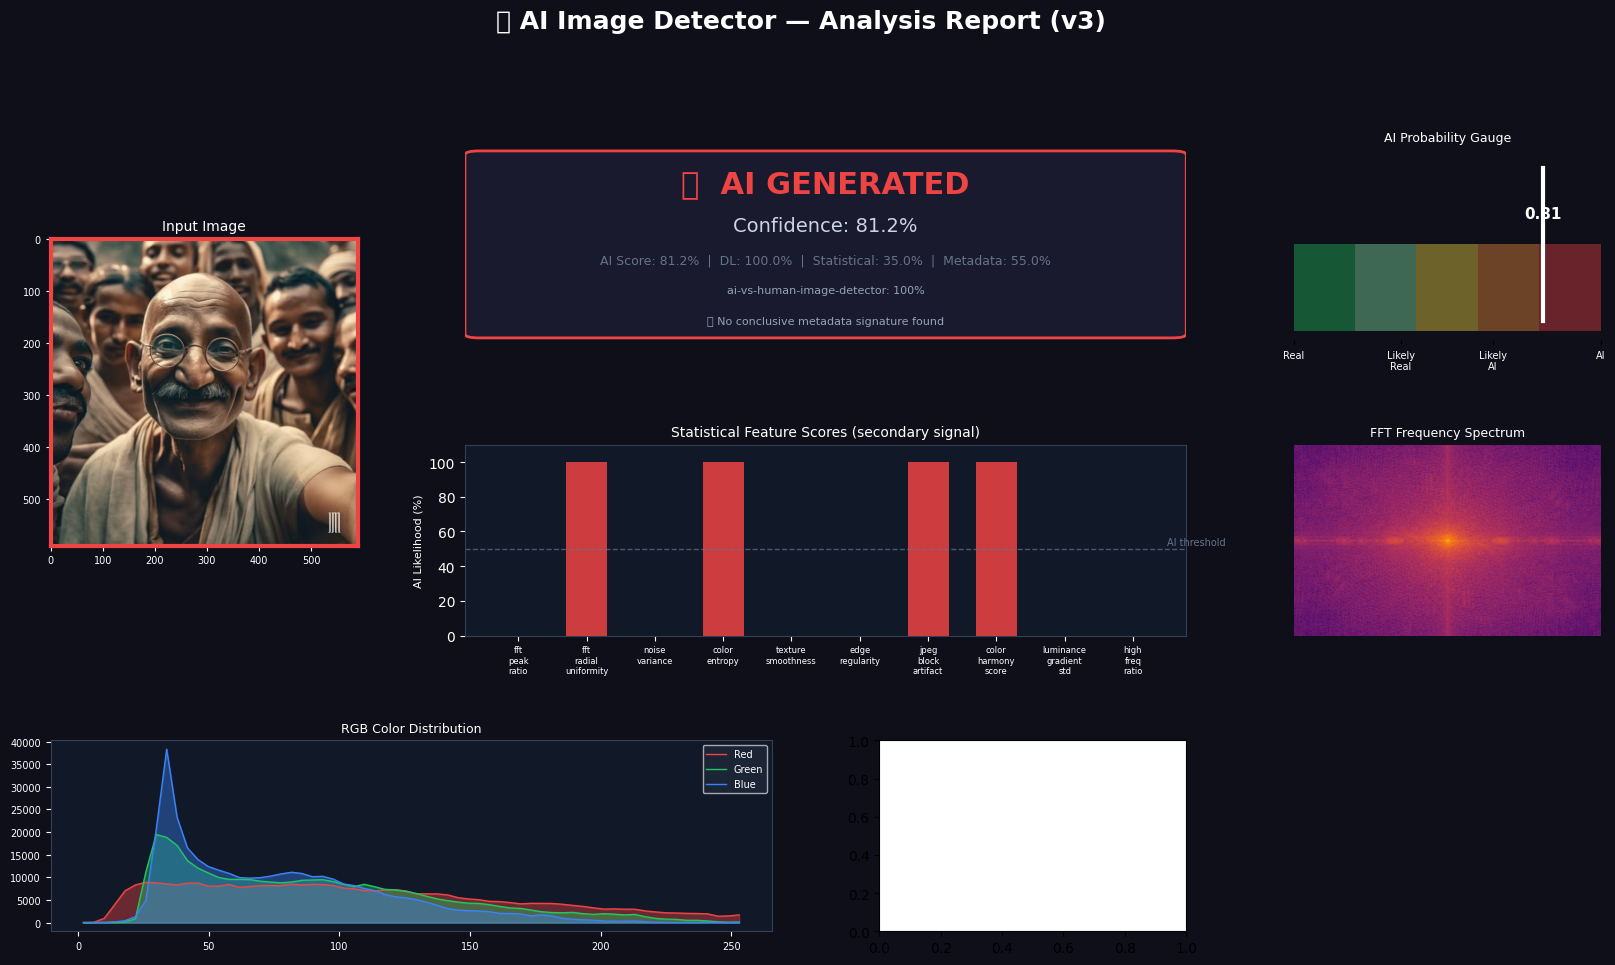

In [ ]:
# ============================================================
# CELL 7: 🚀 MAIN — Upload & Detect!
# ============================================================

def run_detector():
    """Upload an image and detect if it's AI-generated or real."""
    display(HTML("""
    <div style="
      background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
      border: 2px solid #7c3aed;
      border-radius: 12px;
      padding: 20px;
      color: white;
      font-family: 'Segoe UI', sans-serif;
      max-width: 700px;
      margin: 10px 0;
    ">
      <h2 style="color:#a78bfa; margin:0 0 8px 0;">🤖 AI Image Detector (v3)</h2>
      <p style="color:#94a3b8; margin:0 0 12px 0; font-size:13px;">
        Upload any image (JPG, PNG, WebP) to analyze whether it was AI-generated or a real photograph.
      </p>
      <div style="background:#0f172a; border-radius:8px; padding:12px; font-size:12px; color:#64748b;">
        <strong style="color:#94a3b8;">Detection Methods:</strong><br>
        🧠 Ensemble of pretrained, fine-tuned AI-vs-real classifiers (primary)<br>
        🔬 FFT / Noise / Color / Texture / JPEG statistics (secondary, explainable)<br>
        🏷️ Metadata forensics — EXIF / PNG chunks / C2PA AI-tool signatures (new)<br>
        📊 3-way weighted fusion + cross-model agreement check + metadata override
      </div>
    </div>
    """))

    print("\n📁 Please upload an image file...")
    uploaded = files.upload()

    if not uploaded:
        print('❌ No file uploaded.')
        return

    for filename, data in uploaded.items():
        print(f'\n🔍 Analyzing: {filename}')
        print('━' * 50)

        # Load image. Note: PIL's .info dict (PNG text chunks) and EXIF both
        # survive .convert('RGB'), so the metadata stage sees the same
        # object the pixel-based stages do — no separate re-open needed.
        try:
            img = Image.open(io.BytesIO(data)).convert('RGB')
        except Exception as e:
            print(f'❌ Could not load image: {e}')
            continue

        print(f'   📐 Resolution: {img.size[0]} × {img.size[1]} px')
        print('   ⏳ Running analysis pipeline (DL + statistical + metadata)...')

        # Run detection
        results = detector.predict(img)

        # Print text summary
        print('━' * 50)
        emoji = '🤖' if results['verdict'] == 'AI GENERATED' else ('📷' if results['verdict'] == 'REAL IMAGE' else '❓')
        print(f'\n{emoji}  VERDICT:     {results["verdict"]}')
        print(f'📊  CONFIDENCE:  {results["confidence"]*100:.1f}%')
        print(f'🎯  AI SCORE:    {results["final_score"]*100:.1f}%')
        print(f'   ├─ DL ensemble score (primary):    {results["dl_score"]*100:.1f}%')
        print(f'   ├─ Statistical score (secondary):  {results["stat_score"]*100:.1f}%')
        print(f'   └─ Metadata score (corroborating):  {results["meta_score"]*100:.1f}%')

        print('\n🧠 Pretrained model votes:')
        for name, prob in results['dl_breakdown'].items():
            print(f'   {name:<40} {prob*100:5.1f}% AI-likely')
        if results['model_disagreement'] > EnsembleDetector.DISAGREEMENT_THRESHOLD:
            print(f"   ⚠️  Models disagree by {results['model_disagreement']*100:.1f} points — "
                  f"treat this verdict with caution.")

        print('\n🏷️ Metadata forensics:')
        meta = results['meta_report']
        if meta['detected_ai_tool']:
            print(f"   ⚠️  AI generator signature found: {meta['detected_ai_tool']}  (verdict override applied)")
            for field, snippet in meta['detected_ai_evidence'][:5]:
                print(f"      • {field} → matched '{snippet}'")
        if meta['camera_evidence_fields']:
            print(f"   📷  Camera EXIF fields present: {', '.join(meta['camera_evidence_fields'])}")
        if meta['software_tag']:
            print(f"   🖥️  Software tag: {meta['software_tag']}")
        for note in meta['notes']:
            print(f'   ℹ️  {note}')

        print('\n📈 Statistical feature breakdown (secondary signal):')
        for fname, fscore in results['feature_scores'].items():
            bar = '█' * int(fscore * 20)
            label = ' ← AI signal' if fscore > 0.6 else (''
                     if fscore < 0.4 else ' ← borderline')
            print(f'   {fname:<28} {fscore*100:5.1f}% {bar}{label}')

        print('━' * 50)
        print('\n📊 Generating visual report...')

        # Visual report
        visualize_results(img, results)


# Run!
run_detector()
